Different modules

In [24]:
import json
import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd
import os
from collections import defaultdict
from collections import Counter
import re
from nltk.corpus import stopwords
import nltk
from wordcloud import WordCloud

First we are going to get the data from our scraping, which is in data_reddit_query, and then put it into a dataframe.

In [3]:
path = "data_reddit_query"
dfs = []
for filename in os.listdir(path):
    with open(os.path.join(path, filename), "r", encoding="utf-8") as file:
        data = json.load(file)
        try:
            data = data["data"]
            data = data["children"]
            df = pd.json_normalize(data)
            dfs.append(df)
        except:
            pass

df = pd.concat(dfs, ignore_index=True)
    

/tmp/ipykernel_58277/1304277510.py:14: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat(dfs, ignore_index=True)


Removing potential duplicates, this can be done due to all reddit posts URL is unique

In [4]:
df = df.drop_duplicates(subset=['data.permalink'])

In [5]:
df

,kind,data.approved_at_utc,data.subreddit,data.selftext,data.author_fullname,data.saved,data.mod_reason_title,data.gilded,data.clicked,data.title,...,data.media_metadata.kqu29dwabwqf1.s.u,data.media_metadata.kqu29dwabwqf1.id,data.media_metadata.kgwm2bxfbwqf1.status,data.media_metadata.kgwm2bxfbwqf1.e,data.media_metadata.kgwm2bxfbwqf1.m,data.media_metadata.kgwm2bxfbwqf1.p,data.media_metadata.kgwm2bxfbwqf1.s.y,data.media_metadata.kgwm2bxfbwqf1.s.x,data.media_metadata.kgwm2bxfbwqf1.s.u,data.media_metadata.kgwm2bxfbwqf1.id
0,t3,None,Slovenia,"Pozdravljeni sodržavljani,\n\nV EU je bila pre...",t2_6enimyi7,False,None,0.0,False,Boj proti nadzoru privatnih pogovorov na inter...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,t3,None,Slovenia,"The EU's ""Chat Control"" proposal would scan ev...",t2_hdlcyxaao,False,None,0.0,False,EU 'Chat Control' would scan ALL your private ...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,t3,None,Slovenia,"Dragi člani skupnosti,\n\nNajprej: ta objava j...",t2_5g2jc9ml,False,None,0.0,False,"Repost, ker je bilo izbrisano. Obrnite se na s...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,t3,None,Slovenia,Več info: https://fightchatcontrol.eu/,t2_am3ptzg0,False,None,0.0,False,EU želi odobriti ‘chat control’ zakon (CSAM re...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,t3,None,Slovenia,Pred nekaj dnevi sem poslal mail vsem slovensk...,t2_2zt2fwsx,False,None,0.0,False,Chat Control/CSAM - Odgovor Mag. Branko Grims,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
933,t3,None,portugal,Pode dar jeito para explicar a outras pessoa d...,t2_yvz7m,False,None,0.0,False,Video em português a explicar o ChatControl,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
934,t3,None,portugal,,t2_3zo356vb,False,None,0.0,False,Before/After - Portugal and Italy are now in f...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
935,t3,None,portugal,,t2_12y4yc,False,None,0.0,False,EU Council - Current EU Countries' Chat Contro...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
936,t3,None,portugal,[Este post](https://www.reddit.com/r/portugal/...,t2_m1tgx598,False,None,0.0,False,Questionar líderes parlamentares PS/PSD sobre ...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
df = df.astype({'data.selftext': str, 'data.subreddit': str, 'data.title': str})

In [7]:
df.dtypes

kind                                      object
data.approved_at_utc                      object
data.subreddit                            object
data.selftext                             object
data.author_fullname                      object
                                          ...   
data.media_metadata.kgwm2bxfbwqf1.p       object
data.media_metadata.kgwm2bxfbwqf1.s.y    float64
data.media_metadata.kgwm2bxfbwqf1.s.x    float64
data.media_metadata.kgwm2bxfbwqf1.s.u     object
data.media_metadata.kgwm2bxfbwqf1.id      object
Length: 907, dtype: object

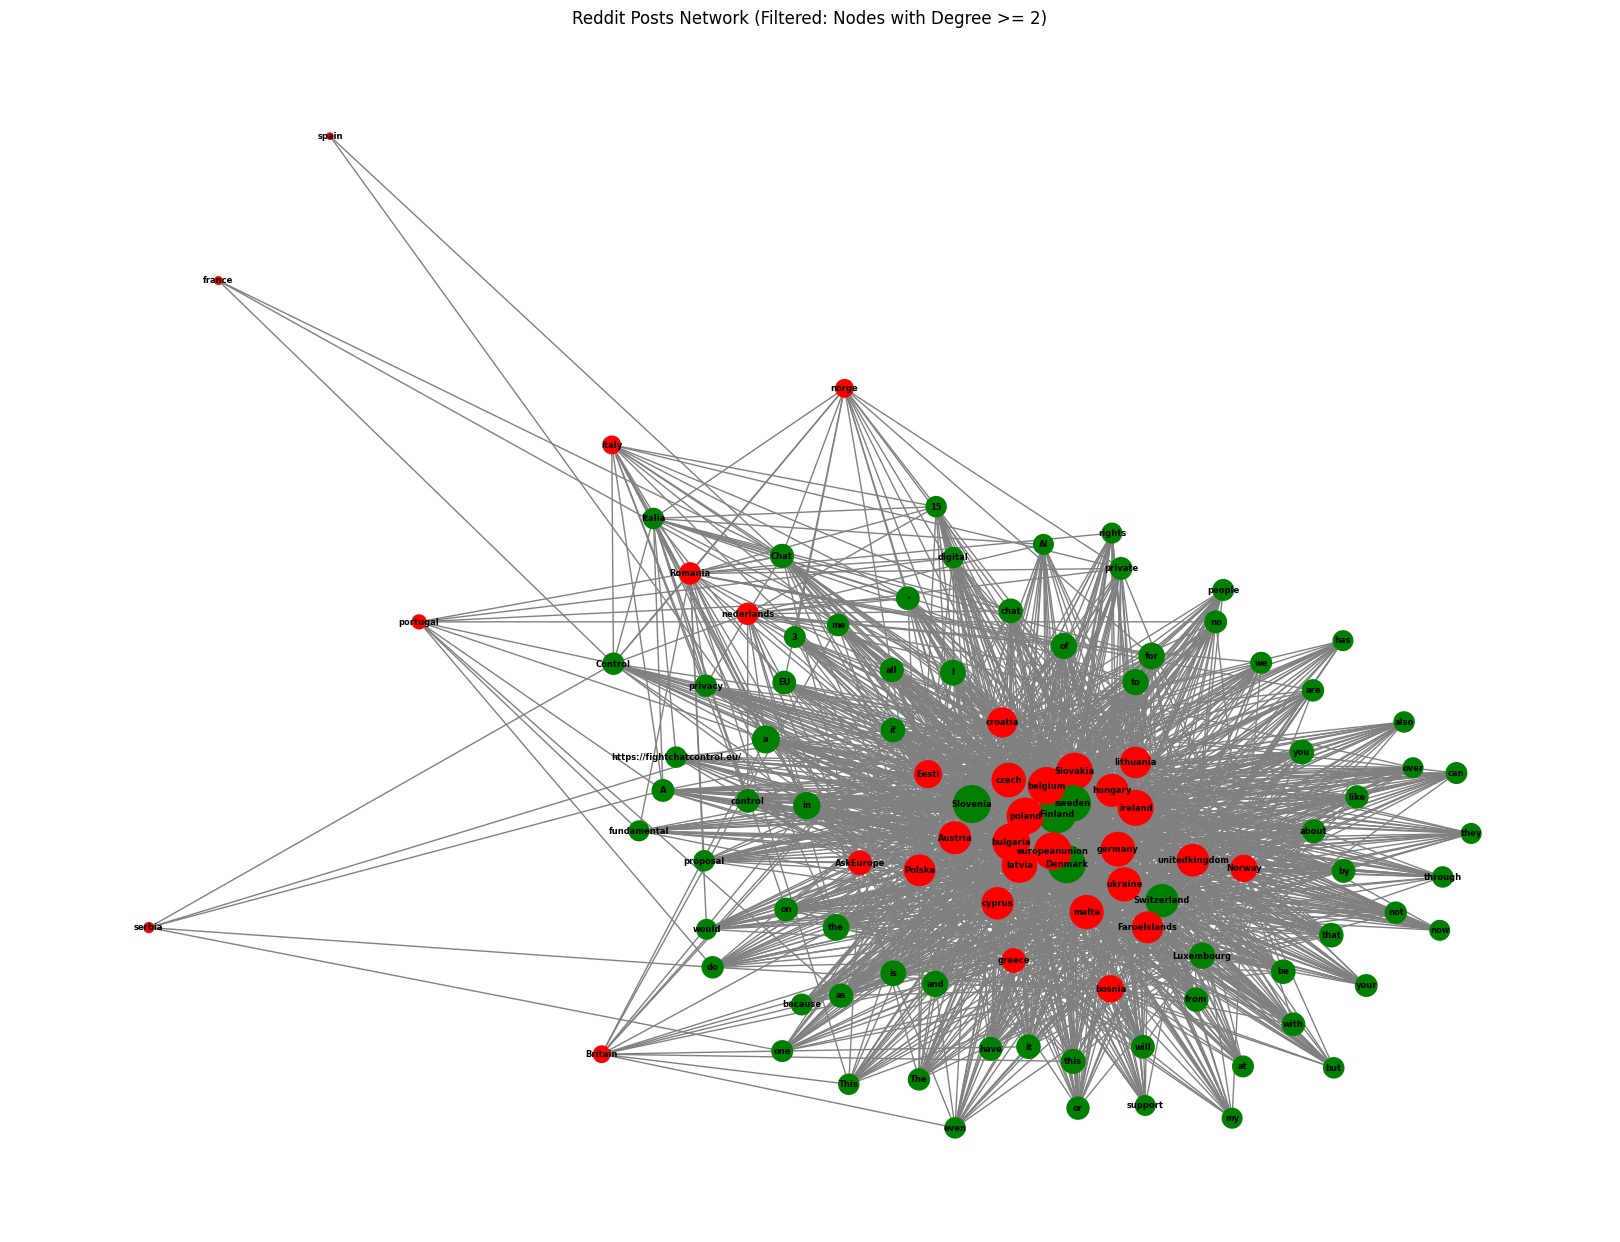

In [8]:

G = nx.Graph()

for _, row in df.iterrows():
    subreddit = row["data.subreddit"]
    title = row["data.title"]
    body = row["data.selftext"]

    if not (subreddit and body and title):
        continue  # skip incomplete entries


    G.add_node(subreddit, type="subreddit")


    # Split title into words and add each as a node
    words = body.split()  # Split by whitespace
    for word in words:
        G.add_node(word, type="word")
        G.add_edge(word, subreddit)  # word belongs to subreddit

# Remove nodes with degree less than 2
degrees = dict(G.degree())
nodes_to_remove = [
    node for node, attrs in G.nodes(data=True)
    if attrs.get("type") == "word" and degrees[node] < 20
]
G.remove_nodes_from(nodes_to_remove)

# Calculate node sizes based on degree (number of connections)
degrees = dict(G.degree())
node_sizes = [degrees[node] * 10 for node in G.nodes()]  # Scale for visibility

# Draw network
plt.figure(figsize=(16, 12))
pos = nx.spring_layout(G, seed=42)

# Color nodes by type
colors = []
for node, attrs in G.nodes(data=True):
    if attrs["type"] == "subreddit":
        colors.append("red")
    else:
        colors.append("green")  # words

nx.draw(
    G,
    pos,
    with_labels=True,
    node_color=colors,
    node_size=node_sizes,  # Use calculated sizes
    font_size=6,
    font_weight="bold",
    edge_color="gray"
)

plt.title("Reddit Posts Network (Filtered: Nodes with Degree >= 2)")
plt.show()


In [9]:
df

,kind,data.approved_at_utc,data.subreddit,data.selftext,data.author_fullname,data.saved,data.mod_reason_title,data.gilded,data.clicked,data.title,...,data.media_metadata.kqu29dwabwqf1.s.u,data.media_metadata.kqu29dwabwqf1.id,data.media_metadata.kgwm2bxfbwqf1.status,data.media_metadata.kgwm2bxfbwqf1.e,data.media_metadata.kgwm2bxfbwqf1.m,data.media_metadata.kgwm2bxfbwqf1.p,data.media_metadata.kgwm2bxfbwqf1.s.y,data.media_metadata.kgwm2bxfbwqf1.s.x,data.media_metadata.kgwm2bxfbwqf1.s.u,data.media_metadata.kgwm2bxfbwqf1.id
0,t3,None,Slovenia,"Pozdravljeni sodržavljani,\n\nV EU je bila pre...",t2_6enimyi7,False,None,0.0,False,Boj proti nadzoru privatnih pogovorov na inter...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,t3,None,Slovenia,"The EU's ""Chat Control"" proposal would scan ev...",t2_hdlcyxaao,False,None,0.0,False,EU 'Chat Control' would scan ALL your private ...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,t3,None,Slovenia,"Dragi člani skupnosti,\n\nNajprej: ta objava j...",t2_5g2jc9ml,False,None,0.0,False,"Repost, ker je bilo izbrisano. Obrnite se na s...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,t3,None,Slovenia,Več info: https://fightchatcontrol.eu/,t2_am3ptzg0,False,None,0.0,False,EU želi odobriti ‘chat control’ zakon (CSAM re...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,t3,None,Slovenia,Pred nekaj dnevi sem poslal mail vsem slovensk...,t2_2zt2fwsx,False,None,0.0,False,Chat Control/CSAM - Odgovor Mag. Branko Grims,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
933,t3,None,portugal,Pode dar jeito para explicar a outras pessoa d...,t2_yvz7m,False,None,0.0,False,Video em português a explicar o ChatControl,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
934,t3,None,portugal,,t2_3zo356vb,False,None,0.0,False,Before/After - Portugal and Italy are now in f...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
935,t3,None,portugal,,t2_12y4yc,False,None,0.0,False,EU Council - Current EU Countries' Chat Contro...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
936,t3,None,portugal,[Este post](https://www.reddit.com/r/portugal/...,t2_m1tgx598,False,None,0.0,False,Questionar líderes parlamentares PS/PSD sobre ...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


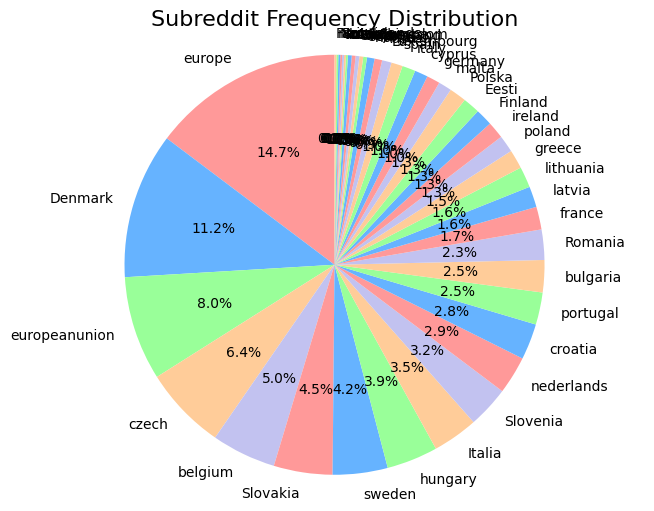

In [10]:
frequency = df['data.subreddit'].value_counts()
colors = ['#ff9999', '#66b3ff', '#99ff99', '#ffcc99', '#c2c2f0'] 

# Create a pie chart
plt.figure(figsize=(8, 6))
plt.pie(
    frequency,
    labels=frequency.index,
    colors=colors,
    autopct='%1.1f%%',  # Show percentages with 1 decimal place
    startangle=90      # Rotate the pie chart for better readability
)

# Add a title
plt.title("Subreddit Frequency Distribution", fontsize=16)

# Equal aspect ratio ensures the pie chart is circular
plt.axis('equal')

# Show the plot
plt.show()

In [11]:
df1 = df
df1['text'] = df['data.title'] + ',' + df['data.selftext']


/tmp/ipykernel_58277/3020144326.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df1['text'] = df['data.title'] + ',' + df['data.selftext']


In [12]:
all_text = ' '.join(df1['text'].astype(str))

In [13]:
nltk.download('stopwords')
# Tokenize words (split into words, ignoring case and punctuation)
words = re.findall(r'\w+', all_text.lower())

english_stopwords = set(stopwords.words('english'))
german_stopwords = set(stopwords.words('german'))
french_stopwords = set(stopwords.words('french'))
danish_stopwords = set(stopwords.words('danish'))
stop_words = english_stopwords.union(german_stopwords, french_stopwords, danish_stopwords)

filtered_words = [word for word in words if word not in stop_words]

word_counts = Counter(filtered_words)

# Count word frequencies
word_freq_df = pd.DataFrame(
    word_counts.items(),
    columns=['word', 'count']
).sort_values('count', ascending=False)

[nltk_data] Downloading package stopwords to
[nltk_data]     /home/inpatch/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [14]:
word_freq_df

,word,count
75,chat,913
76,control,874
46,https,719
5,na,316
1244,europa,316
...,...,...
26301,aguardo,1
26300,agradeço,1
26299,expectativas,1
26298,suas,1


In [15]:
top_10_words = word_counts.most_common(20)
top_10_df = pd.DataFrame(top_10_words, columns=['word', 'count'])

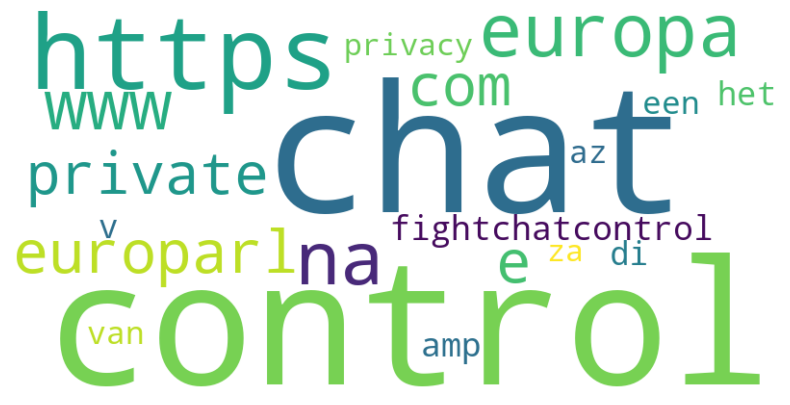

In [25]:
# Create a dictionary of words and their sizes
word_size_dict = dict(zip(top_10_df['word'], top_10_df['count']))

# Generate the word cloud
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate_from_frequencies(word_size_dict)

# Display the word cloud
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

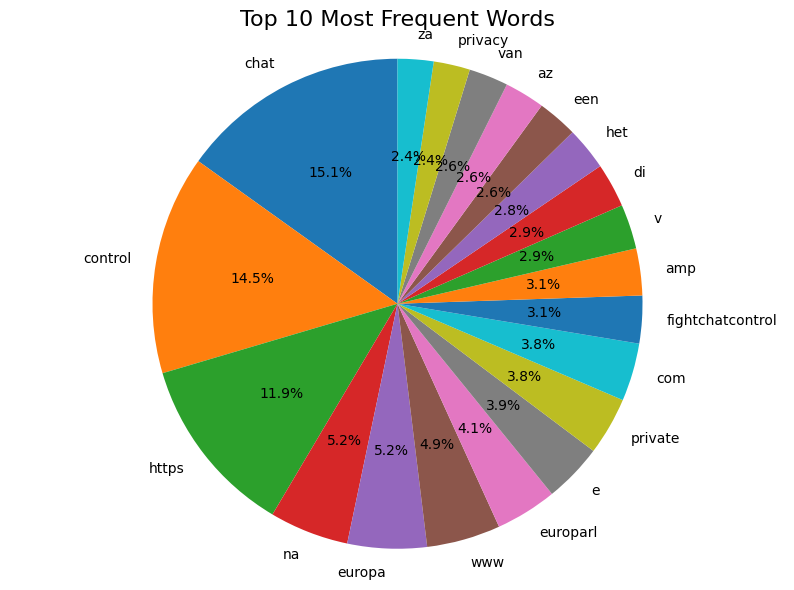

In [16]:
# Define colors for each slice
colors = plt.cm.Paired(range(len(top_10_words)))

# Create the pie plot
plt.figure(figsize=(10, 7))
plt.pie(
    top_10_df['count'],
    labels=top_10_df['word'],
    autopct='%1.1f%%',
    startangle=90
)

# Add a title
plt.title("Top 10 Most Frequent Words", fontsize=16)

# Equal aspect ratio ensures the pie is circular
plt.axis('equal')

# Show the plot
plt.show()

Hvem laver opslag

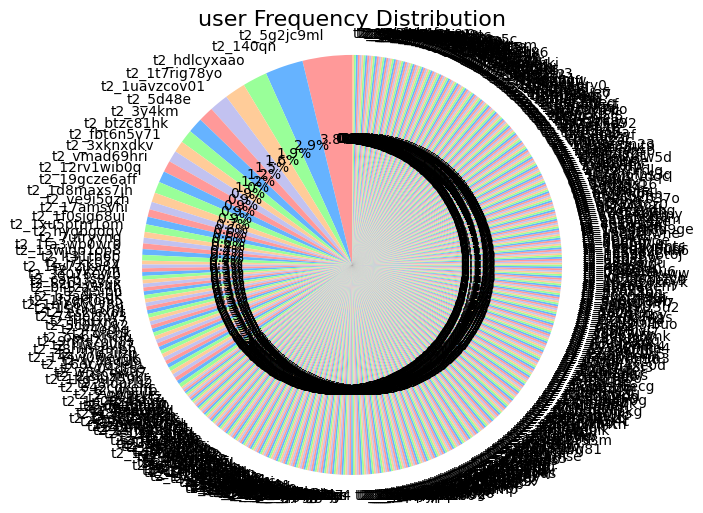

In [17]:
frequency = df['data.author_fullname'].value_counts()
colors = ['#ff9999', '#66b3ff', '#99ff99', '#ffcc99', '#c2c2f0'] 

# Create a pie chart
plt.figure(figsize=(8, 6))
plt.pie(
    frequency,
    labels=frequency.index,
    colors=colors,
    autopct='%1.1f%%',  # Show percentages with 1 decimal place
    startangle=90      # Rotate the pie chart for better readability
)

# Add a title
plt.title("user Frequency Distribution", fontsize=16)

# Equal aspect ratio ensures the pie chart is circular
plt.axis('equal')

# Show the plot
plt.show()

In [18]:
frequency

data.author_fullname
t2_5g2jc9ml      26
t2_140qn         20
t2_hdlcyxaao     13
t2_1t7rig78yo    11
t2_1uavzcov01    10
                 ..
t2_ygvkq          1
t2_9mqvx          1
t2_ga34z          1
t2_45bfqk4f       1
t2_86n1s          1
Name: count, Length: 504, dtype: int64

In [27]:
df2 = df
df2['date_column'] = pd.to_datetime(df['data.created'])

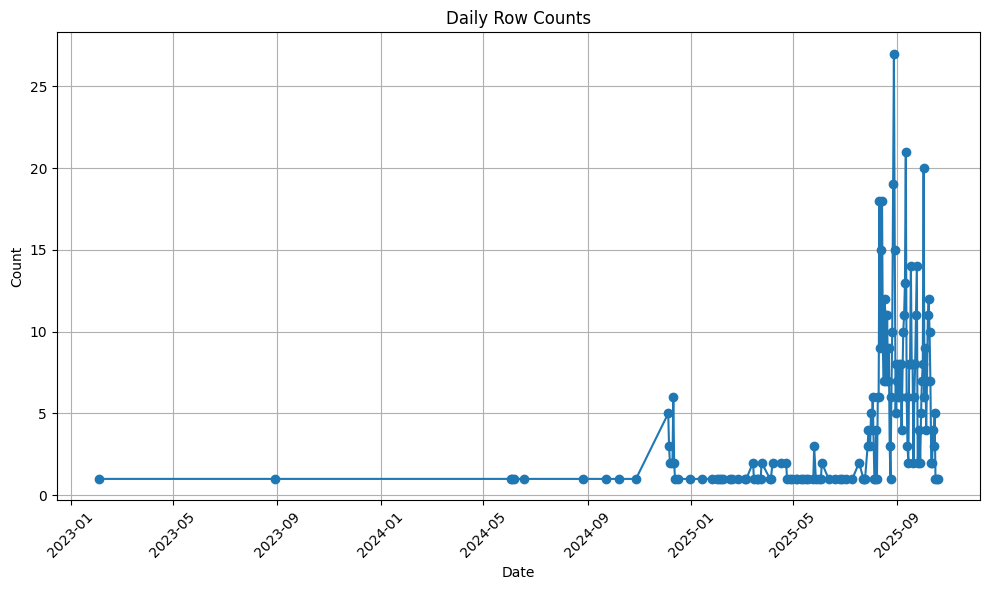

In [28]:
df2['datetime'] = pd.to_datetime(df2['data.created'], unit='s')
df2 = df2[df2['datetime'] >= '2020-01-01']
daily_counts = df2.groupby(df2['datetime'].dt.date).size().reset_index(name='count')

# Plot
plt.figure(figsize=(10, 6))
plt.plot(daily_counts['datetime'], daily_counts['count'], marker='o')
plt.title('Daily Row Counts')
plt.xlabel('Date')
plt.ylabel('Count')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()